# Scikit Learn Basics

In [17]:
# Lifecycle
# Getting data ready
# Choosing ML model
# Fit Model
# Evaluate Model
# Improve the model
# Save Model
# Summary

In [3]:
import pandas as pd

In [21]:
## Getting Data Ready

In [4]:
heart_disease = pd.read_csv("Heart Disease UCI.csv")

In [5]:
heart_disease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,40,1,3,152,223,0,0,181,0,0.0,0,0,2,1
293,39,1,3,118,219,0,0,140,0,1.2,1,0,2,1
294,35,1,3,120,198,0,0,130,1,1.6,1,0,2,1
295,35,0,3,138,183,0,0,182,0,1.4,0,0,0,0


In [6]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [12]:
# Create X
X = heart_disease.drop('condition', axis=1)
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,40,1,3,152,223,0,0,181,0,0.0,0,0,2
293,39,1,3,118,219,0,0,140,0,1.2,1,0,2
294,35,1,3,120,198,0,0,130,1,1.6,1,0,2
295,35,0,3,138,183,0,0,182,0,1.4,0,0,0


In [13]:
# Create Y
Y = heart_disease['condition']
Y

0      0
1      0
2      0
3      1
4      0
      ..
292    1
293    1
294    1
295    0
296    1
Name: condition, Length: 297, dtype: int64

In [22]:
## Choosing ML model

In [20]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier()

clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [23]:
## Fit The Model

In [25]:
from sklearn.model_selection import train_test_split
X_test, X_train, Y_test, Y_train = train_test_split(X, Y , test_size=0.3)

In [27]:
clf.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [28]:
## Evaluate the model

In [29]:
predicted_y = clf.predict(X_test)
predicted_y

array([0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0])

In [30]:
clf.score(X_train, Y_train)

1.0

In [31]:
clf.score(X_test, Y_test)

0.7922705314009661

In [32]:
## Improve the model

In [38]:
for i in range(10,200,10):
    print(f'Running model with {i} estimators')
    clf = RandomForestClassifier(n_estimators=i).fit(X_train, Y_train)
    print(f'Accuracy is : {clf.score(X_test, Y_test)}')

Running model with 10 estimators
Accuracy is : 0.782608695652174
Running model with 20 estimators
Accuracy is : 0.8019323671497585
Running model with 30 estimators
Accuracy is : 0.8019323671497585
Running model with 40 estimators
Accuracy is : 0.8019323671497585
Running model with 50 estimators
Accuracy is : 0.7922705314009661
Running model with 60 estimators
Accuracy is : 0.7971014492753623
Running model with 70 estimators
Accuracy is : 0.7922705314009661
Running model with 80 estimators
Accuracy is : 0.8115942028985508
Running model with 90 estimators
Accuracy is : 0.8019323671497585
Running model with 100 estimators
Accuracy is : 0.8164251207729468
Running model with 110 estimators
Accuracy is : 0.8019323671497585
Running model with 120 estimators
Accuracy is : 0.7922705314009661
Running model with 130 estimators
Accuracy is : 0.7971014492753623
Running model with 140 estimators
Accuracy is : 0.7971014492753623
Running model with 150 estimators
Accuracy is : 0.7874396135265701
Runni

In [40]:
## Save Model

In [41]:
import pickle

In [42]:
pickle.dump(clf,open('heart_disease.pkl','wb'))

In [43]:
load_model = pickle.load(open('heart_disease.pkl','rb'))
load_model.score(X_test, Y_test)

0.8019323671497585

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
heart_disease = pd.read_csv('Heart Disease UCI.csv')

In [4]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [5]:
X = heart_disease.drop('condition', axis=1)
Y = heart_disease['condition']

In [8]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0


In [9]:
Y.head()

0    0
1    0
2    0
3    1
4    0
Name: condition, dtype: int64

In [20]:
from sklearn.model_selection import train_test_split
X_test, X_train, Y_test, Y_train = train_test_split(X, Y , test_size=0.25)

In [13]:
X_train.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
dtype: object

In [3]:
phones_data= pd.read_csv('phone_data_large.csv')

# Getting Data Ready

In [4]:
phones_data

,Make,Colour,Memory(kb),Sim Cards,Price
0,Iphone,Black,11179,5,$220.00
1,Motorola,White,213095,4,$350.00
2,Nokia,Green,99213,4,$450.00
3,Samsung,Blue,45698,4,$750.00
4,Nokia,White,150043,4,$400.00
5,Nokia,Green,99213,4,$450.00
6,Samsung,Blue,45698,4,$750.00
7,Samsung,Blue,54738,4,$700.00
8,Nokia,White,60000,4,$625.00
9,Motorola,White,31600,4,$970.00


In [6]:
phones_data.dtypes

Make            str
Colour          str
Memory(kb)    int64
Sim Cards     int64
Price           str
dtype: object

# Converting Types

In [7]:
phones_data['Price']= phones_data['Price'].str[:-2]

In [8]:
phones_data

,Make,Colour,Memory(kb),Sim Cards,Price
0,Iphone,Black,11179,5,$220.
1,Motorola,White,213095,4,$350.
2,Nokia,Green,99213,4,$450.
3,Samsung,Blue,45698,4,$750.
4,Nokia,White,150043,4,$400.
5,Nokia,Green,99213,4,$450.
6,Samsung,Blue,45698,4,$750.
7,Samsung,Blue,54738,4,$700.
8,Nokia,White,60000,4,$625.
9,Motorola,White,31600,4,$970.


In [13]:
phones_data['Price']=phones_data['Price'].str.replace(r"[\$\,\.]","",regex=True).astype(int)
phones_data.dtypes

Make            str
Colour          str
Memory(kb)    int64
Sim Cards     int64
Price         int64
dtype: object

In [14]:
phones_data

,Make,Colour,Memory(kb),Sim Cards,Price
0,Iphone,Black,11179,5,220
1,Motorola,White,213095,4,350
2,Nokia,Green,99213,4,450
3,Samsung,Blue,45698,4,750
4,Nokia,White,150043,4,400
5,Nokia,Green,99213,4,450
6,Samsung,Blue,45698,4,750
7,Samsung,Blue,54738,4,700
8,Nokia,White,60000,4,625
9,Motorola,White,31600,4,970


In [17]:
X=phones_data.drop('Price',axis=1)
Y=phones_data['Price']

In [26]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

features_cat=["Make", "Colour", "Sim Cards"]
t_features= OneHotEncoder()

transformer = ColumnTransformer([("One_transformed",t_features,features_cat)],
                               remainder="passthrough")
transformed_X = transformer.fit_transform(X)
pd.DataFrame(transformed_X)

,0,1,2,3,4,5,6,7,8,9,10
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,11179.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,213095.0
2,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,99213.0
3,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,45698.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,150043.0
5,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,99213.0
6,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,45698.0
7,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,54738.0
8,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,60000.0
9,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,31600.0


In [28]:
transformed_new=pd.get_dummies(phones_data[["Make","Colour","Sim Cards"]])
transformed_new

,Sim Cards,Make_Iphone,Make_Motorola,Make_Nokia,Make_Samsung,Colour_Black,Colour_Blue,Colour_Green,Colour_White
0,5,True,False,False,False,True,False,False,False
1,4,False,True,False,False,False,False,False,True
2,4,False,False,True,False,False,False,True,False
3,4,False,False,False,True,False,True,False,False
4,4,False,False,True,False,False,False,False,True
5,4,False,False,True,False,False,False,True,False
6,4,False,False,False,True,False,True,False,False
7,4,False,False,False,True,False,True,False,False
8,4,False,False,True,False,False,False,False,True
9,4,False,True,False,False,False,False,False,True


In [29]:
X_test, X_train, Y_test, Y_train = train_test_split(transformed_new, Y , test_size=0.25)

In [31]:
phones_model.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [32]:
phones_model.score(X_test,Y_test)

0.09920291971667539

In [33]:
phone_missing_values=pd.read_csv('phone_data_1000_rows_missing_values.csv')

In [34]:
phone_missing_values.head()

,Make,Colour,Memory(kb),Sim Cards,Price
0,Iphone,Blue,9833.0,1.0,$1415.00
1,Nokia,White,62210.0,1.0,$1210.00
2,Motorola,Green,112694.0,2.0,$1179.00
3,Nokia,Silver,72650.0,1.0,$1465.00
4,Iphone,Green,39433.0,1.0,NaN


In [35]:
phone_missing_values.isna().sum()

Make          50
Colour        50
Memory(kb)    50
Sim Cards     50
Price         50
dtype: int64

In [52]:
# Fill missing values in string columns
phone_missing_values['Make'] = phone_missing_values['Make'].fillna('missing')
phone_missing_values['Colour'] = phone_missing_values['Colour'].fillna('missing')

# Convert numeric columns properly
phone_missing_values['Memory(kb)'] = pd.to_numeric(phone_missing_values['Memory(kb)'], errors='coerce')
phone_missing_values['Sim Cards'] = pd.to_numeric(phone_missing_values['Sim Cards'], errors='coerce')

# Fill missing values in numeric columns
mean_value_memory = phone_missing_values['Memory(kb)'].mean()
phone_missing_values['Memory(kb)'] = phone_missing_values['Memory(kb)'].fillna(mean_value_memory)

mean_value_sim = phone_missing_values['Sim Cards'].mean()
phone_missing_values['Sim Cards'] = phone_missing_values['Sim Cards'].fillna(mean_value_sim)

In [53]:
phone_missing_values.isna().sum()

Make           0
Colour         0
Memory(kb)     0
Sim Cards      0
Price         50
dtype: int64

In [61]:
phone_missing_values.dropna(subset=['Price'],inplace=True)

In [62]:
phone_missing_values.isna().sum()

Make          0
Colour        0
Memory(kb)    0
Sim Cards     0
Price         0
dtype: int64

In [66]:
from sklearn.impute import SimpleImputer

# Categorical imputer
cat_imputer = SimpleImputer(strategy='constant', fill_value='missing')

# Numerical imputer
num_imputer = SimpleImputer(strategy='mean')

# Convert numeric columns properly
phone_missing_values['Memory(kb)'] = pd.to_numeric(
    phone_missing_values['Memory(kb)'],
    errors='coerce'
)

phone_missing_values['Sim Cards'] = pd.to_numeric(
    phone_missing_values['Sim Cards'],
    errors='coerce'
)

# Apply imputers
filled_make = cat_imputer.fit_transform(phone_missing_values[['Make']])
filled_colour = cat_imputer.fit_transform(phone_missing_values[['Colour']])

filled_memory = num_imputer.fit_transform(phone_missing_values[['Memory(kb)']])
filled_sim = num_imputer.fit_transform(phone_missing_values[['Sim Cards']])

# Put everything back into dataframe
# Put everything back into dataframe
phone_missing_values['Make'] = filled_make.ravel()

phone_missing_values['Colour'] = filled_colour.ravel()

phone_missing_values['Memory(kb)'] = filled_memory.ravel()

phone_missing_values['Sim Cards'] = filled_sim.ravel()

# View dataframe
phone_missing_values.head()

,Make,Colour,Memory(kb),Sim Cards,Price
0,Iphone,Blue,9833.0,1.0,$1415.00
1,Nokia,White,62210.0,1.0,$1210.00
2,Motorola,Green,112694.0,2.0,$1179.00
3,Nokia,Silver,72650.0,1.0,$1465.00
5,Nokia,Black,115438.0,2.0,$312.00


In [67]:
phone_missing_values.isna().sum()

Make          0
Colour        0
Memory(kb)    0
Sim Cards     0
Price         0
dtype: int64

In [71]:
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

# Load dataset
housing = fetch_california_housing()

# Convert into DataFrame
df_boston = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

# Add target column
df_boston["target"] = housing.target

# To reproduce same results
np.random.seed(1)

# Create X and y
X = df_boston.drop("target", axis=1)
y = df_boston["target"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2
)

# Create Ridge model
reg_model = Ridge()

# Train model
reg_model.fit(X_train, y_train)

# Check score
score = reg_model.score(X_test, y_test)

print(score)

0.5965957761160752


In [73]:
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Load dataset
housing = fetch_california_housing()

# Convert into DataFrame
df_boston = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

# Add target column
df_boston["target"] = housing.target

# Reproducible results
np.random.seed(1)

# Create features and labels
X = df_boston.drop("target", axis=1)
y = df_boston["target"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2
)

# Create Random Forest Regressor model
rf_model = RandomForestRegressor()

# Train model
rf_model.fit(X_train, y_train)

# Check score
score = rf_model.score(X_test, y_test)

print(score)

0.8070687053407989


In [75]:
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split

# Load dataset
heart_disease = pd.read_csv("Heart Disease UCI.csv")

# Features and target
X = heart_disease.drop("condition", axis=1)
y = heart_disease["condition"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
svc_model = LinearSVC(max_iter=5000)

# Train model
svc_model.fit(X_train, y_train)

# Check accuracy
score = svc_model.score(X_test, y_test)

print("LinearSVC Accuracy:", score)

LinearSVC Accuracy: 0.7333333333333333


In [76]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Load dataset
heart_disease = pd.read_csv("Heart Disease UCI.csv")

# Features and target
X = heart_disease.drop("condition", axis=1)
y = heart_disease["condition"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
clf = RandomForestClassifier()

# Train model
clf.fit(X_train, y_train)

# Check accuracy
score = clf.score(X_test, y_test)

print("Random Forest Accuracy:", score)

Random Forest Accuracy: 0.75


AUC Score: 0.8588169642857142


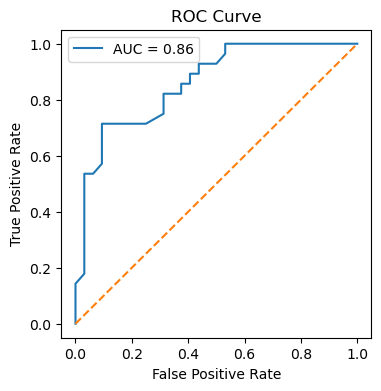

In [82]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score

# Load dataset
heart_disease = pd.read_csv("Heart Disease UCI.csv")

# Features and target
X = heart_disease.drop("condition", axis=1)
y = heart_disease["condition"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
clf = RandomForestClassifier()

# Train model
clf.fit(X_train, y_train)

# Predict probabilities
y_probs = clf.predict_proba(X_test)

# Keep probabilities for class 1
y_probs_positive = y_probs[:, 1]

# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_probs_positive)

# Calculate AUC Score
auc_score = roc_auc_score(y_test, y_probs_positive)

print("AUC Score:", auc_score)

# Plot ROC Curve
plt.figure(figsize=(4,4))

plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")

# Random baseline
plt.plot([0, 1], [0, 1], linestyle='--')

# Labels
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [79]:
import sys
!conda install --yes --prefix {sys.prefix} seaborn

Jupyter detected...
3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Users\user\OneDrive\Desktop\ml_project\venv

  added / updated specs:
    - seaborn


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    seaborn-0.13.2             |  py314haa95532_3         691 KB
    ------------------------------------------------------------
                                           Total:         691 KB

The following NEW packages will be INSTALLED:

  seaborn            pkgs/main/win-64::seaborn-0.13.2-py314haa95532_3 



seaborn-0.13.2       | 691 KB    |            |   0% 
seaborn-0.13.2       | 691 KB    | 2          |   2% 
seaborn-0.13.2       | 691 KB    | ##7        |  28% 
seaborn-0.13.2       | 691 KB    | #####      |  51% 
seaborn-0.13.2       | 691 KB    | #######6



==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.0

Please update conda by running

    $ conda update -n base -c defaults conda




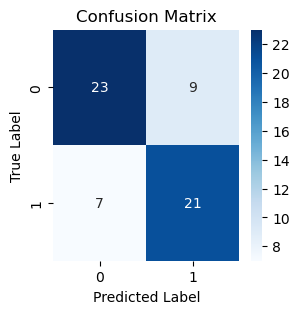

In [81]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Make predictions
y_preds = clf.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_preds)

# Plot confusion matrix
plt.figure(figsize=(3,3))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

# Labels
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [83]:
from sklearn.metrics import classification_report

# Make predictions
y_preds = clf.predict(X_test)

# Generate classification report
report = classification_report(y_test, y_preds)

# Print report
print(report)

              precision    recall  f1-score   support

           0       0.75      0.75      0.75        32
           1       0.71      0.71      0.71        28

    accuracy                           0.73        60
   macro avg       0.73      0.73      0.73        60
weighted avg       0.73      0.73      0.73        60



In [84]:
import pandas as pd

from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Load dataset
housing = fetch_california_housing()

# Create dataframe
df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

# Add target
df["target"] = housing.target

# Features and target
X = df.drop("target", axis=1)
y = df["target"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = RandomForestRegressor()

# Train model
model.fit(X_train, y_train)

# Predictions
y_preds = model.predict(X_test)

# Calculate R2 score
r2 = r2_score(y_test, y_preds)

print("R2 Score:", r2)

R2 Score: 0.8065504828087307
